# Task 3 — Distributions and relationships

**Data Visualization — Week 1 assignment, Task 3** · dataset: `data/penguins.csv`

344 penguins, 3 species, 3 islands (the Palmer Penguins data, Antarctica 2007–2009).

| Step | Question | Chart |
|---|---|---|
| 1 | What shape is the distribution of body mass? | Histogram |
| 2 | Does splitting by species explain that shape? | Histograms as small multiples |
| 3 | How are bill length and bill depth related? | Scatter plot — and a Simpson's paradox |
| 4 | How does average body mass differ by species **and** sex? | Grouped bar |

## 0. Setup

Same house style as the lecture notebook: the eight-hue colour-blind-safe palette, recessive grid, no chart
border, titles on the left. Every chart below inherits it, and every chart is also saved to `charts/`.

I added one small helper, `footnote()`, because several charts in this task have to **declare excluded
rows on the chart itself**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette (same as the lecture) ---------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"
SERIES = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]

INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

# ---- House style ---------------------------------------------------
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name):
    # Every chart is also exported to charts/ so it can go straight into a report.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE)


def footnote(ax, text, y=-0.18):
    # Small grey note under the chart - used to declare exclusions ON the chart.
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


---

# Meet the data — and its missing values

The brief warns this dataset has gaps. Find them before plotting anything.

In [2]:
penguins = pd.read_csv(DATA / "penguins.csv")
print("Rows:", penguins.shape[0], " Columns:", penguins.shape[1])
penguins.head()

Rows: 344  Columns: 7


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
missing = penguins.isna().sum()
missing = missing[missing > 0]
pd.DataFrame({"missing": missing, "percent": (missing / len(penguins) * 100).round(1)})

,missing,percent
bill_length_mm,2,0.6
bill_depth_mm,2,0.6
flipper_length_mm,2,0.6
body_mass_g,2,0.6
sex,11,3.2


In [4]:
# Who exactly is missing what?
measures = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
no_measures = penguins[penguins[measures].isna().all(axis=1)]
print("Missing ALL four measurements:", len(no_measures))
print(no_measures[["species", "island", "sex"]].to_string())
print()
only_sex = penguins["sex"].isna() & penguins[measures].notna().all(axis=1)
print("Measured, but sex unrecorded:", int(only_sex.sum()))
print(penguins.loc[only_sex, "species"].value_counts().to_string())

Missing ALL four measurements: 2
    species     island  sex
3    Adelie  Torgersen  NaN
339  Gentoo     Biscoe  NaN

Measured, but sex unrecorded: 9
species
Adelie    5
Gentoo    4


So there are **11 incomplete rows**, in two kinds:

- **2 penguins have no measurements at all** (one Adelie, one Gentoo). They are also missing `sex` — these 2
  are part of the 11. They carry nothing but a species label, so they cannot appear on any chart.
- **9 more penguins were measured but their sex was not recorded.**

**My decision, chart by chart:**

| Chart | Needs | Penguins used | Excluded |
|---|---|---|---|
| Steps 1–3 | measurements only | **342** | the 2 unmeasured |
| Step 4 | measurements **and** sex | **333** | all 11 |

I do **not** guess (impute) the missing sexes. Body mass differs by sex, so a guessed sex would partly be
based on the very thing Step 4 measures — circular. Dropping 9 of 342 (under 3%) costs very little. Every
chart states its exclusions in a footnote.

In [5]:
df = penguins.copy()
df["sex"] = df["sex"].str.capitalize()  # "MALE" -> "Male": label for humans

measured = df.dropna(subset=measures)        # Steps 1-3
complete = measured.dropna(subset=["sex"])   # Step 4

print("All penguins:      ", len(df))
print("Measured (1-3):    ", len(measured))
print("Measured + sex (4):", len(complete))

# One colour per species, used consistently in every chart of this notebook.
SPECIES_COLOUR = {"Adelie": BLUE, "Chinstrap": ORANGE, "Gentoo": AQUA}

All penguins:       344
Measured (1-3):     342
Measured + sex (4): 333


---

# Step 1 — The distribution of body mass

**Question:** how is body mass spread across the colony? That is a question about the shape of *one continuous
variable*, which makes it a **histogram**. The bars touch because body mass is continuous; bins are 150 g wide.

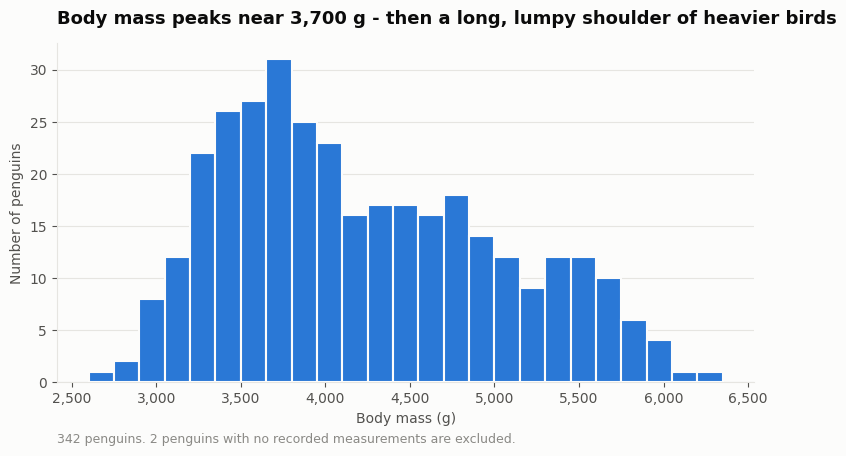

In [6]:
bins = np.arange(2600, 6451, 150)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(measured["body_mass_g"], bins=bins, color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)

ax.set_title("Body mass peaks near 3,700 g - then a long, lumpy shoulder of heavier birds")
ax.set_xlabel("Body mass (g)")
ax.set_ylabel("Number of penguins")
ax.xaxis.set_major_formatter(lambda v, p: f"{v:,.0f}")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
footnote(ax, f"{len(measured)} penguins. 2 penguins with no recorded measurements are excluded.")

save(fig, "task3_01_body_mass_hist")
plt.show()

In [7]:
print("Mean:  ", round(measured["body_mass_g"].mean()), "g")
print("Median:", round(measured["body_mass_g"].median()), "g")

Mean:   4202 g
Median: 4050 g


**What shape is it?** Not one tidy hump. There is a clear peak at 3,500–4,000 g, but instead of tailing off
smoothly the counts drop to a **broad plateau from about 4,200 to 5,700 g** — a second, flatter hump sitting on
the right of the first — before finally falling away at 6,300 g. Overall it is **right-skewed** (the mean,
4,202 g, sits above the median, 4,050 g).

So: one dominant hump, plus a shoulder too wide and too flat to be an ordinary tail. A shape like that is a
warning sign that **two groups have been mixed together** — which Step 2 tests.

---

# Step 2 — Split by species

Same histogram, same bins, but one panel per species, stacked so they share the x-axis — **small multiples**.
Each panel keeps the whole-colony histogram in grey behind it, so you can see which part of the original shape
each species is responsible for.

I chose small multiples over overlapping histograms in one panel: three semi-transparent histograms on top of
each other produce muddy mixed colours exactly where Adelie and Chinstrap overlap, which is the interesting part.

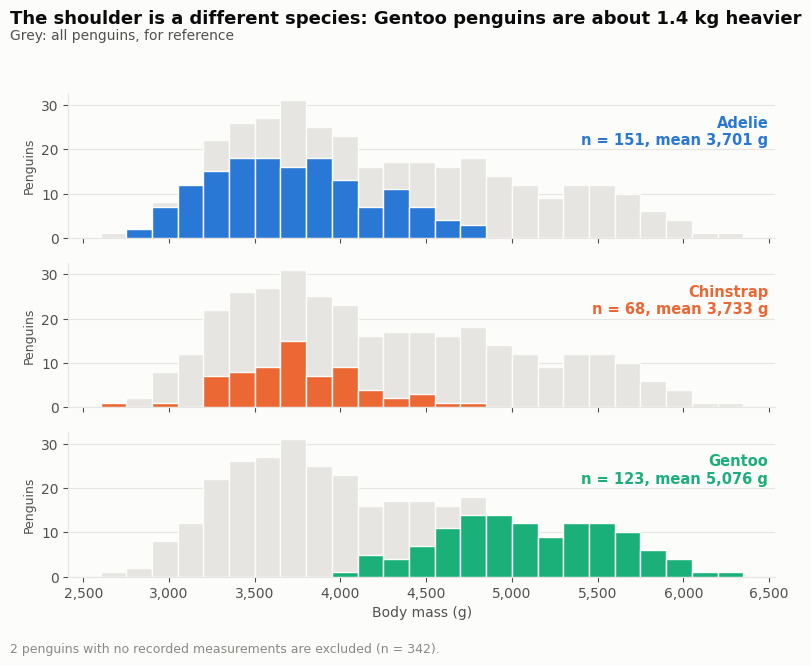

In [8]:
order = (
    measured.groupby("species")["body_mass_g"].mean().sort_values().index.tolist()
)

fig, axes = plt.subplots(3, 1, figsize=(8, 6.6), sharex=True, sharey=True)

for ax, species in zip(axes, order):
    group = measured[measured["species"] == species]
    # Context: the whole colony, in grey.
    ax.hist(measured["body_mass_g"], bins=bins, color=GRID, edgecolor=SURFACE, linewidth=1, zorder=2)
    # Message: this species, in its colour.
    ax.hist(group["body_mass_g"], bins=bins, color=SPECIES_COLOUR[species],
            edgecolor=SURFACE, linewidth=1, zorder=3)
    ax.text(
        0.99, 0.85,
        f"{species}\nn = {len(group)}, mean {group['body_mass_g'].mean():,.0f} g",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10.5, fontweight="bold", color=SPECIES_COLOUR[species],
    )
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.set_ylabel("Penguins", fontsize=9)

axes[-1].set_xlabel("Body mass (g)")
axes[-1].xaxis.set_major_formatter(lambda v, p: f"{v:,.0f}")

fig.suptitle(
    "The shoulder is a different species: Gentoo penguins are about 1.4 kg heavier",
    x=0.005, ha="left", fontsize=13, fontweight="bold", color=INK,
)
fig.text(0.005, 0.935, "Grey: all penguins, for reference", fontsize=10, color=INK_SOFT)
fig.text(0.005, 0.005, "2 penguins with no recorded measurements are excluded (n = 342).",
         fontsize=9, color=INK_MUTED)
fig.tight_layout(rect=[0, 0.03, 1, 0.93])

save(fig, "task3_02_body_mass_by_species")
plt.show()

**Yes — species explains the shape completely.** Each species on its own is a single, roughly symmetric hump.

- **Adelie** (mean ≈ 3,700 g) and **Chinstrap** (≈ 3,730 g) are almost the same size, and together they make
  the big left hump.
- **Gentoo** (≈ 5,080 g) make the whole shoulder and the right tail by themselves.

The "right skew" of Step 1 was not a property of penguins; it was the result of pouring two populations of
different size into one histogram.

---

# Step 3 — Bill length vs bill depth (the important one)

Two numeric variables, and the question is whether they move together: that is a **scatter plot**. Colour
carries species — the variable that turns out to change the answer. I add two kinds of trend line:

- one **dashed grey line** fitted to *all* penguins pooled together, and
- one **solid line per species**, fitted only to that species.

In [9]:
# The correlations, before drawing anything.
r_all = measured["bill_length_mm"].corr(measured["bill_depth_mm"])
r_by_species = measured.groupby("species").apply(
    lambda g: g["bill_length_mm"].corr(g["bill_depth_mm"]), include_groups=False
)
print(f"All penguins pooled: r = {r_all:+.2f}")
print(r_by_species.round(2).map("{:+.2f}".format).to_string())

All penguins pooled: r = -0.24
species
Adelie       +0.39
Chinstrap    +0.65
Gentoo       +0.64


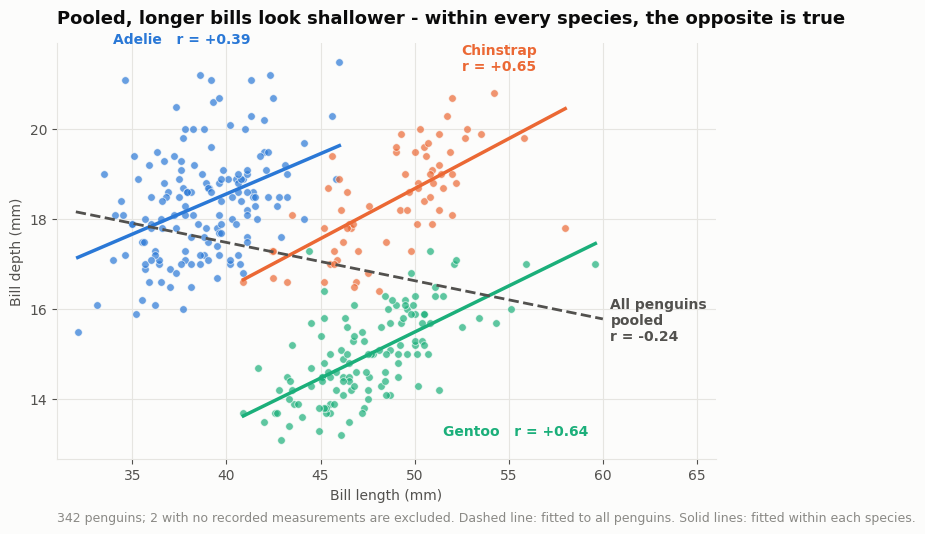

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 5.4))

for species, colour in SPECIES_COLOUR.items():
    g = measured[measured["species"] == species]
    ax.scatter(g["bill_length_mm"], g["bill_depth_mm"], s=30, color=colour, alpha=0.7,
               edgecolor=SURFACE, linewidth=0.6, zorder=3)
    # Within-species trend line, over that species' own range.
    slope, intercept = np.polyfit(g["bill_length_mm"], g["bill_depth_mm"], 1)
    xs = np.array([g["bill_length_mm"].min(), g["bill_length_mm"].max()])
    ax.plot(xs, slope * xs + intercept, color=colour, linewidth=2.5, zorder=4)

# Pooled trend line - ignoring species.
slope, intercept = np.polyfit(measured["bill_length_mm"], measured["bill_depth_mm"], 1)
xs = np.array([32, 60])
ax.plot(xs, slope * xs + intercept, color=INK_SOFT, linewidth=2, linestyle="--", zorder=5)

# Direct labels instead of a legend.
ax.text(34.0, 21.9, f"Adelie   r = {r_by_species['Adelie']:+.2f}", color=BLUE, fontweight="bold", fontsize=10)
ax.text(52.5, 21.3, f"Chinstrap\nr = {r_by_species['Chinstrap']:+.2f}", color=ORANGE, fontweight="bold", fontsize=10)
ax.text(51.5, 13.2, f"Gentoo   r = {r_by_species['Gentoo']:+.2f}", color=AQUA, fontweight="bold", fontsize=10)
ax.text(60.4, 15.75, f"All penguins\npooled\nr = {r_all:+.2f}", color=INK_SOFT, fontsize=10, fontweight="bold", va="center")

ax.set_title("Pooled, longer bills look shallower - within every species, the opposite is true")
ax.set_xlabel("Bill length (mm)")
ax.set_ylabel("Bill depth (mm)")
ax.set_xlim(31, 66)
ax.set_axisbelow(True)
footnote(ax, "342 penguins; 2 with no recorded measurements are excluded. "
             "Dashed line: fitted to all penguins. Solid lines: fitted within each species.", y=-0.15)

save(fig, "task3_03_simpsons_paradox_bills")
plt.show()

### What is going on: Simpson's paradox

Pool every penguin together and the dashed line slopes **down** (r = −0.24): longer bills seem to come with
shallower bills. Look within any one species and the line slopes **up** (r = +0.39 to +0.65): a longer bill
comes with a *deeper* bill, which is what you would expect — bigger birds have bigger bills in both directions.

Both statements are computed correctly from the same data. The contradiction comes from a third variable,
**species**, which affects both measurements at once:

- **Adelie** have *short, deep* bills (top-left cluster).
- **Gentoo** have *long, shallow* bills (bottom-right cluster).
- **Chinstrap** have long and deep bills (top-right).

When the groups are mixed, the pooled line is mostly fitted to the *gap between* the Adelie and Gentoo clusters
— from top-left to bottom-right — and that between-group slope is negative. It swamps the positive slope that
exists inside every group. This reversal of a trend when groups are combined is called **Simpson's paradox**,
and species here is a **confounding variable**.

> **Why it matters:** if you only ever computed the pooled correlation, you would confidently report the
> wrong sign. The pooled number answers "across *different kinds* of penguin, how do bill shapes differ?", not
> "for a penguin, does a longer bill mean a shallower one?". The only defence is the one from the lecture:
> plot it, and plot your groups separately. Colour by group is not decoration on this chart — it is the
> finding.

---

# Step 4 — Average body mass by species **and** sex

Two categorical variables and one number to compare: the lecture's **grouped bar** — the ceiling of what one
chart should hold. Species are sorted by mass (they have no natural order); within each species, female and
male sit side by side because the male–female comparison is half the message. Bars start at zero, so a bar
twice as long really is twice as heavy.

In [11]:
by_species_sex = (
    complete.groupby(["species", "sex"])["body_mass_g"]
    .agg(mean_mass="mean", penguins="size")
    .round(0)
    .reset_index()
)
by_species_sex

,species,sex,mean_mass,penguins
0,Adelie,Female,3369.0,73
1,Adelie,Male,4043.0,73
2,Chinstrap,Female,3527.0,34
3,Chinstrap,Male,3939.0,34
4,Gentoo,Female,4680.0,58
5,Gentoo,Male,5485.0,61


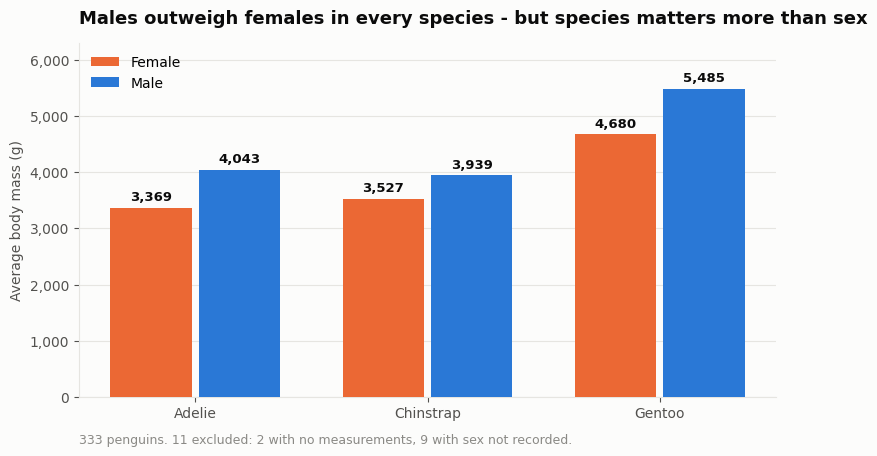

In [12]:
species_order = complete.groupby("species")["body_mass_g"].mean().sort_values().index.tolist()
x = np.arange(len(species_order))
width = 0.38

fig, ax = plt.subplots(figsize=(9, 4.6))
# Sex is the grouping variable, so it gets the colour. Two hues from the house palette.
for i, (sex, colour) in enumerate([("Female", ORANGE), ("Male", BLUE)]):
    values = [
        by_species_sex.query("species == @s and sex == @sex")["mean_mass"].iloc[0]
        for s in species_order
    ]
    bars = ax.bar(x + (i - 0.5) * width, values, width=width * 0.92, color=colour, label=sex, zorder=3)
    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 70, f"{value:,.0f}",
                ha="center", va="bottom", fontsize=9.5, fontweight="bold", color=INK)

ax.set_xticks(x)
ax.set_xticklabels(species_order)
ax.set_title("Males outweigh females in every species - but species matters more than sex")
ax.set_ylabel("Average body mass (g)")
ax.set_ylim(0, 6300)
ax.yaxis.set_major_formatter(lambda v, p: f"{v:,.0f}")
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.legend(loc="upper left")
footnote(ax, "333 penguins. 11 excluded: 2 with no measurements, 9 with sex not recorded.", y=-0.13)

save(fig, "task3_04_mass_species_sex")
plt.show()

**Reading it:** in every species males are heavier, by roughly 400–800 g. But the species gap is bigger: a
**female Gentoo (4,680 g) is heavier than a male of either other species** (≈ 4,040 g Adelie, 3,940 g
Chinstrap). So if you wanted to guess a penguin's weight, knowing its species tells you more than knowing its
sex — which is exactly why the species split was needed in Steps 2 and 3.

---

## Summary of chart choices

| Step | Chart | Why |
|---|---|---|
| 1 | Histogram | Shape of one continuous variable |
| 2 | Histogram small multiples, shared axes | Compare shapes across groups without overlapping colours |
| 3 | Scatter coloured by species + trend lines | Relationship between two numbers — and the group variable that reverses it |
| 4 | Grouped bar, zero baseline | One number compared across two categories |